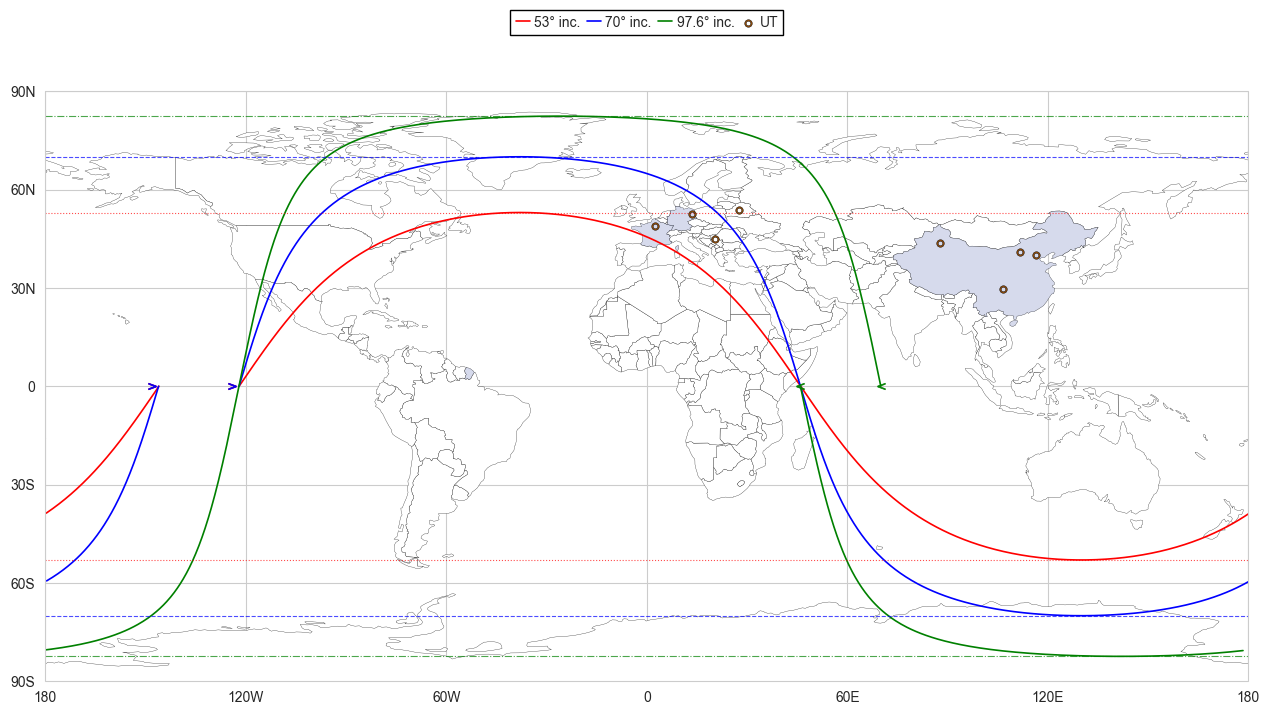

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas
from matplotlib import colors
import cartopy.crs as ccrs
from cartopy.io import shapereader as shpreader
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

# ============ 简单的轨道地面迹工具函数（替代 geospatial_plot_utils） ============
R_EARTH = 6378.137
MU = 398600.4418
SIDEREAL_DAY = 86164.0905
OMEGA_E = 2 * np.pi / SIDEREAL_DAY

def get_coords(inc_deg, raan_deg, alt_km, num_points, begin_time, portion=1):
    """
    返回一个轨道周期内的地面迹点列表：[(lat, lon), ...]
    这里简单用圆轨道 + 地球自转，忽略 begin_time 和 portion 的物理精确性，
    只是保证能画出和论文类似的轨道弧线。
    """
    inc = np.radians(inc_deg)
    raan = np.radians(raan_deg)

    a = R_EARTH + alt_km
    T = 2 * np.pi * np.sqrt(a**3 / MU)
    t = np.linspace(0, T, num_points)

    theta = 2 * np.pi * t / T  # 真近点角

    # 纬度
    sin_phi = np.sin(inc) * np.sin(theta)
    sin_phi = np.clip(sin_phi, -1.0, 1.0)
    phi = np.arcsin(sin_phi)
    lat = np.degrees(phi)

    # 赤经 + RAAN
    cos_i = np.cos(inc)
    alpha = np.arctan2(cos_i * np.sin(theta), np.cos(theta))
    alpha_unwrapped = np.unwrap(alpha) + raan

    # 格林尼治恒星时
    gst = OMEGA_E * t
    lam = np.degrees(alpha_unwrapped - gst)

    lon = ((lam + 180) % 360) - 180  # wrap 到 [-180,180]

    return list(zip(lat, lon)), None, None

def plot_period_groundtrack(coords, ax, color, label=None):
    """
    在给定 GeoAxes 上画一条地面迹，coords 为 [(lat, lon), ...]
    自动在经度跳变处断开。
    """
    lats = np.array([c[0] for c in coords])
    lons = np.array([c[1] for c in coords])

    segments = []
    cur_lon, cur_lat = [], []
    for i in range(len(lons)):
        if i > 0 and abs(lons[i] - lons[i-1]) > 180:
            if cur_lon:
                segments.append((np.array(cur_lon), np.array(cur_lat)))
            cur_lon, cur_lat = [], []
        cur_lon.append(lons[i])
        cur_lat.append(lats[i])
    if cur_lon:
        segments.append((np.array(cur_lon), np.array(cur_lat)))

    for lon_seg, lat_seg in segments:
        ax.plot(lon_seg, lat_seg,
                color=color, linewidth=1.2,
                transform=ccrs.PlateCarree(),
                label=label)
        # 只第一个 segment 用 label
        label = None

# ====================== 原始绘图逻辑（去掉外部数据） ============================
continents = ["AF", "AS", "EU", "NA", "OC", "SA"]
cols = ["#c1d5e2", "#ce9c7f", "#7598b6", "#6a7465", "#914c09", "#663979", "#fbe17b"]

# 使用 Cartopy 自带的 Natural Earth 数据
shpfilename = shpreader.natural_earth(
    resolution='110m', category='cultural', name='admin_0_countries'
)
world = geopandas.read_file(shpfilename)

# 自动选择国家名列
if "name" in world.columns:
    NAME_COL = "name"
elif "NAME" in world.columns:
    NAME_COL = "NAME"
elif "NAME_LONG" in world.columns:
    NAME_COL = "NAME_LONG"
else:
    print("Warning: 未找到国家名列，不高亮国家。")
    NAME_COL = None

fig, ax = plt.subplots(figsize=(12.8, 7.2), subplot_kw={'projection': ccrs.PlateCarree()})

cmap = colors.ListedColormap(cols[:-2])
world.plot(facecolor="white", edgecolor="black", ax=ax, linewidth=0.2)

# 高亮几个示例国家（代替外部 countries）
# countries = ["United States of America", "Germany", "Australia"]
countries = ["China", "Germany","France"]

def plotCountryPatch(axes, country_name, fcolor):
    if NAME_COL is None:
        return
    nami = world[world[NAME_COL] == country_name]
    if nami.empty:
        return
    geom = nami.geometry
    axes.add_geometries(
        geom,
        crs=ccrs.PlateCarree(),
        facecolor=fcolor,
        edgecolor="none",
        alpha=0.2,
        zorder=2,
    )

for c in countries:
    plotCountryPatch(ax, c, "#364aa0")

begin_time = 1679408909

# 53° 轨道
coords, bc1, bc2 = get_coords(53, 238, 550, 1000, begin_time, portion=1)
plot_period_groundtrack(coords, ax, "red", label="53° inc.")
to_scatter = [coords[0], coords[-1]]
ax.scatter(
    [latlon[1] - 2 for latlon in to_scatter],
    [latlon[0] for latlon in to_scatter],
    marker='$>$', zorder=10, color="red", s=30.0, linewidths=0.5,
    transform=ccrs.PlateCarree()
)

# 70° 轨道
coords, bc1, bc2 = get_coords(70, 238, 570, 1000, begin_time, portion=1)
plot_period_groundtrack(coords, ax, "blue", label="70° inc.")
to_scatter = [coords[0], coords[-1]]
ax.scatter(
    [latlon[1] - 2 for latlon in to_scatter],
    [latlon[0] for latlon in to_scatter],
    marker='$>$', zorder=10, color="blue", s=30.0, linewidths=0.5,
    transform=ccrs.PlateCarree()
)

# 97.6° 轨道
coords, bc1, bc2 = get_coords(97.6, 70, 560, 1000, begin_time, portion=1)
plot_period_groundtrack(coords, ax, "green", label="97.6° inc.")
to_scatter = [coords[0], coords[-1]]
ax.scatter(
    [latlon[1] for latlon in to_scatter],
    [latlon[0] for latlon in to_scatter],
    marker='$<$', zorder=10, color="green", s=30.0, linewidths=0.5,
    transform=ccrs.PlateCarree()
)

# 纬度覆盖线
def plot_extent(inclination, color="r", lw=1.4, alpha=0.7, lt="dotted"):
    if inclination > 90:
        inclination = 90 - (inclination % 90)
    ax.plot(
        [-180, 180], [inclination, inclination],
        linewidth=lw, color=color, linestyle=lt, alpha=alpha,
        transform=ccrs.PlateCarree()
    )
    ax.plot(
        [-180, 180], [-inclination, -inclination],
        linewidth=lw, color=color, linestyle=lt, alpha=alpha,
        transform=ccrs.PlateCarree()
    )

plot_extent(53, "r", lt="dotted", lw=0.8)
plot_extent(70, "b", lt="dashed", lw=0.8)
plot_extent(97.6, "g", lt="dashdot", lw=0.8)

# 简单构造几个 GS / PoP 点（替代 gateway_df / pop_df）
# gateway_df = pd.DataFrame({
#     "lat": [47.6, 25.8, -33.9, 38.9, 52.5],
#     "long": [-122.3, -80.2, 151.2, -77.0, 13.4],
# })
gateway_df = pd.DataFrame({
    "lat": [
        39.90,  # Beijing
        29.56,  # Chongqing
        43.82,  # Urumqi
        40.84,  # Hohhot
        52.52,  # Berlin
        48.85,  # Paris
        53.90,  # Minsk
        44.78   # Belgrade
    ],
    "long": [
        116.40,  # Beijing
        106.55,  # Chongqing
        87.62,   # Urumqi
        111.75,  # Hohhot
        13.40,   # Berlin
        2.35,    # Paris
        27.56,   # Minsk
        20.44    # Belgrade
    ]
})


# pop_df = pd.DataFrame({
#     "lat": [40.7, 51.5, 35.7, -37.8],
#     "long": [-74.0, -0.12, 139.8, 145.0],
# })

def plot_gsdata(gsdata_df, ax, label, marker, color, size=10, lw=0.6):
    latitude, longitude = gsdata_df["lat"], gsdata_df["long"]
    ax.scatter(
        longitude, latitude,
        s=size,
        color=color,
        zorder=10,
        marker=marker,
        linewidths=lw,
        edgecolors="black" if marker == "$\\circ$" else "white",
        transform=ccrs.PlateCarree(),
        label=label,
    )

ax.set_extent([-180, 180, -90, 90], ccrs.PlateCarree())


# ax.get_xaxis().set_ticks([])
# ax.get_yaxis().set_ticks([])
# ==== 增加经纬度刻度 ====
xticks = np.arange(-180, 181, 60)   # 经度刻度：-180, -120, ..., 180
yticks = np.arange(-90, 91, 30)     # 纬度刻度：-90, -60, ..., 90
ax.set_xticks(xticks, crs=ccrs.PlateCarree())
ax.set_yticks(yticks, crs=ccrs.PlateCarree())

lon_formatter = LongitudeFormatter(number_format='.0f', degree_symbol='')
lat_formatter = LatitudeFormatter(number_format='.0f', degree_symbol='')
ax.xaxis.set_major_formatter(lon_formatter)
ax.yaxis.set_major_formatter(lat_formatter)

# 绘制地面显示点
plot_gsdata(gateway_df, ax, "UT", "$\\circ$", cols[4], 30, lw=0.3)
# plot_gsdata(pop_df, ax, "PoP", "v", "blue", 20, lw=0.3)

ax.legend(
    loc='upper center', bbox_to_anchor=(0.50, 1.15),
    ncol=5, edgecolor="k", handlelength=1, labelspacing=0.06,
    columnspacing=0.5, fancybox=False, shadow=False,
    handletextpad=0.3, framealpha=1.0
).set_zorder(100)

plt.axis('tight')
plt.tight_layout()

result_path = "../paper_dataresult"  # 当前目录
plt.savefig(f"{result_path}/fig01_inclination_starlink_comparison_with_gws.pdf",dpi=300,
            bbox_inches="tight", pad_inches=0)


plt.savefig(f"{result_path}/fig01_inclination_starlink_comparison_with_gws.svg",
            bbox_inches="tight", pad_inches=0)
plt.show()


In [6]:
import json  # 新增：用于读取 snapshot100.json


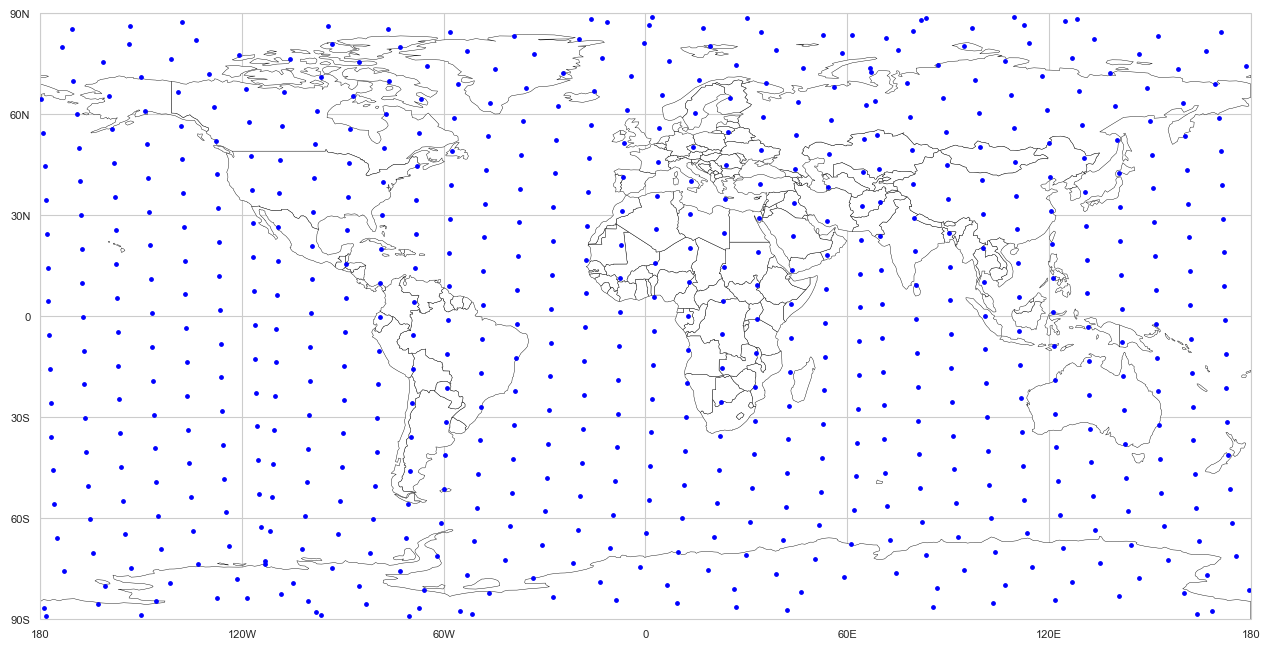

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas
import cartopy.crs as ccrs
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from cartopy.io import shapereader as shpreader  # 新增

# ===== 读取世界底图（用 cartopy 的 natural_earth） =====
shpfilename = shpreader.natural_earth(
    resolution="110m", category="cultural", name="admin_0_countries"
)
world = geopandas.read_file(shpfilename)

# 创建投影坐标轴
fig, ax = plt.subplots(
    figsize=(12.8, 7.2),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

# 画国家边界
world.plot(
    facecolor="white",
    edgecolor="black",
    linewidth=0.3,
    ax=ax,
)

# # ========= 这里开始添加一个卫星（蓝点） =========
# sat_lat = 30.0   # 卫星纬度，自己改
# sat_lon = 0.0    # 卫星经度，自己改
#
# ax.scatter(
#     sat_lon,
#     sat_lat,
#     transform=ccrs.PlateCarree(),
#     s=8,               # 点大小，可调
#     color="blue",
#     marker="o",
#     zorder=5,
# )
# # ========= 卫星结束 =========


# ========= 这里开始：从 snapshot100.json 读取所有卫星并绘制 =========
with open("../Cartopy/snapshot_100.json", "r", encoding="utf-8") as f:
    snapshot = json.load(f)

# 典型结构：{"satellites": [{"id":0,"lat":...,"lng":...,"alt":...}, ...]}
sat_list = snapshot.get("satellites", [])

# 兼容 "lng" 或 "lon" 作为经度字段名
lats = []
lons = []
for s in sat_list:
    lat = s.get("lat")
    lon = s.get("lng", s.get("lon"))
    if lat is None or lon is None:
        continue
    lats.append(lat)
    lons.append(lon)

ax.scatter(
    lons,
    lats,
    transform=ccrs.PlateCarree(),
    s=6,             # 单点小一点，类似示例图
    color="blue",
    marker="o",
    zorder=5,
)
# ========= 卫星结束 =========




# 设置显示范围
ax.set_extent([-180, 180, -90, 90], crs=ccrs.PlateCarree())

# ===== 经纬度刻度 =====
xticks = np.arange(-180, 181, 60)   # 经度刻度：-180, -120, ..., 180
yticks = np.arange(-90, 91, 30)     # 纬度刻度：-90, -60, ..., 90

ax.set_xticks(xticks, crs=ccrs.PlateCarree())
ax.set_yticks(yticks, crs=ccrs.PlateCarree())

lon_formatter = LongitudeFormatter(number_format='.0f', degree_symbol='')
lat_formatter = LatitudeFormatter(number_format='.0f', degree_symbol='')
ax.xaxis.set_major_formatter(lon_formatter)
ax.yaxis.set_major_formatter(lat_formatter)

ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig("world_map_only.pdf", dpi=300, bbox_inches="tight", pad_inches=0)
plt.show()


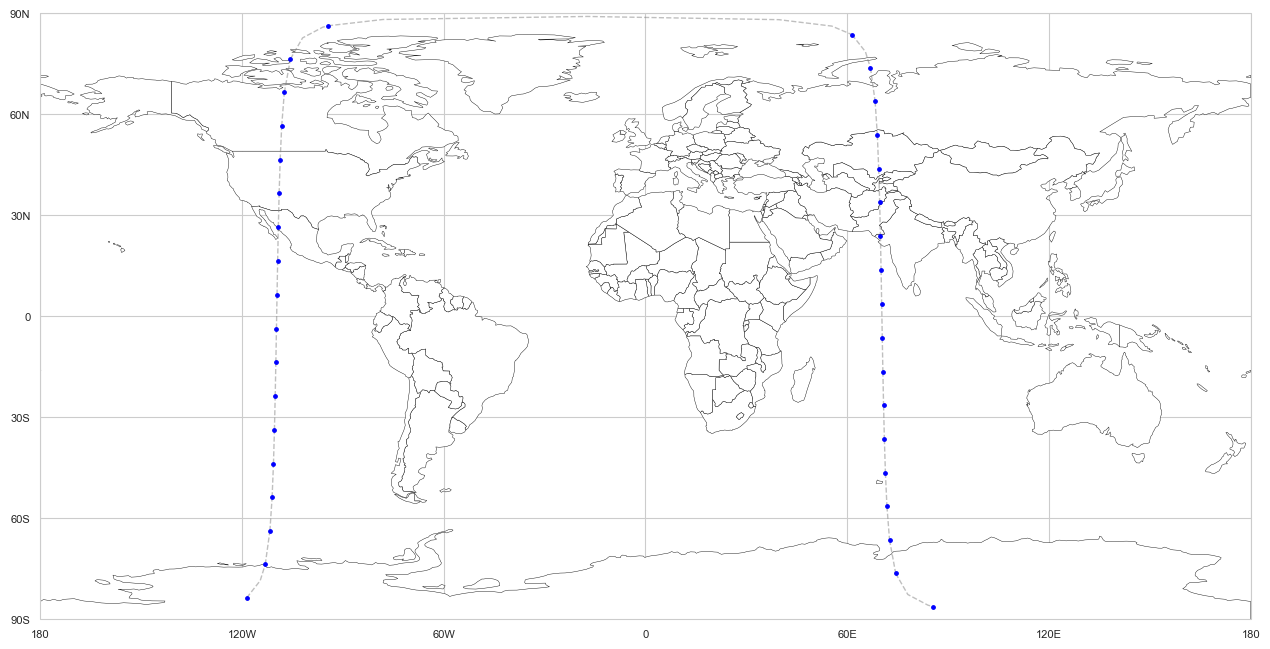

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas
import cartopy.crs as ccrs
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from cartopy.io import shapereader as shpreader
import json
from geopy.distance import geodesic  # 使用 geopy 来计算大圆弧

# 读取世界底图（用 cartopy 的 natural_earth）
shpfilename = shpreader.natural_earth(
    resolution="110m", category="cultural", name="admin_0_countries"
)
world = geopandas.read_file(shpfilename)

# 创建投影坐标轴
fig, ax = plt.subplots(
    figsize=(12.8, 7.2),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

# 画国家边界
world.plot(
    facecolor="white",
    edgecolor="black",
    linewidth=0.3,
    ax=ax,
)

# 从 snapshot100.json 读取所有卫星并绘制
with open("../paper_dataresult/snapshot_100.json", "r", encoding="utf-8") as f:
    snapshot = json.load(f)

sat_list = snapshot.get("satellites", [])

# 兼容 "lng" 或 "lon" 作为经度字段名
satellites = {}
for s in sat_list:
    lat = s.get("lat")
    lon = s.get("lng", s.get("lon"))
    if lat is None or lon is None:
        continue
    sat_id = s.get("id")
    orbit = s.get("orbit", 0)  # 假设每颗卫星有一个 orbit 属性来区分轨道
    if orbit not in satellites:
        satellites[orbit] = []
    satellites[orbit].append((sat_id, lat, lon))

# 只选择编号 0 到 35 的卫星
selected_satellites = {}
for orbit, sat_list in satellites.items():
    selected_satellites[orbit] = [sat for sat in sat_list if 0 <= int(sat[0]) <= 35]

# 绘制卫星点
for sat_list in selected_satellites.values():
    lats = [sat[1] for sat in sat_list]
    lons = [sat[2] for sat in sat_list]
    ax.scatter(
        lons, lats, transform=ccrs.PlateCarree(),
        s=6, color="blue", marker="o", zorder=5
    )

# 绘制同轨卫星之间的曲线（大圆弧）
def draw_great_circle(ax, lat1, lon1, lat2, lon2, color="gray"):
    # 使用 geopy 计算大圆弧上的中间点
    distance = geodesic((lat1, lon1), (lat2, lon2))  # 计算两点之间的大圆弧距离
    num_points = 100  # 中间点的数量

    # 获取大圆弧上的点
    lats, lons = [], []
    for i in range(num_points + 1):
        # 在两点之间均匀插值
        point = distance.interpolate(i / num_points)  # 获取大圆弧上的每个点
        lat, lon = point.latitude, point.longitude
        lats.append(lat)
        lons.append(lon)

    # 绘制大圆弧
    ax.plot(lons, lats, transform=ccrs.PlateCarree(), color=color, linestyle='-', linewidth=1, zorder=3)

# ================== 修改开始 ==================

# 优化后的绘制逻辑（绘制曲线）
for orbit, sat_list in selected_satellites.items():
    # 1. 按经度排序
    sat_list.sort(key=lambda x: x[2])

    # 2. 提取经纬度
    lats = [s[1] for s in sat_list]
    lons = [s[2] for s in sat_list]

    if not lons:
        continue

    # 3. 逐段绘制，使用 Geodetic 变换实现曲线效果
    # 注意：不能再一次性传整个列表给 ax.plot 并使用 Geodetic，
    # 因为 Geodetic 会试图找所有点之间的最短路径，可能会导致跨越日界线时的连线错误。
    # 最稳妥的方法是两两连接，或者分段处理。

    # 为了性能和效果的平衡，我们依然检测日界线，但在段内绘制时使用 Geodetic

    for i in range(len(lons) - 1):
        lon1, lat1 = lons[i], lats[i]
        lon2, lat2 = lons[i+1], lats[i+1]

        # 检查经度跳变 (跨越日界线)
        if abs(lon2 - lon1) > 180:
            continue # 跨越日界线时不直接连线，或者需要特殊处理拆分

        # 使用 Geodetic 变换绘制两点间的曲线
        ax.plot(
            [lon1, lon2], [lat1, lat2],
            transform=ccrs.Geodetic(),  # <--- 关键修改：使用大地坐标系
            color="gray", linestyle='--', # 曲线通常用实线效果更好，也可以用 '--'
            linewidth=1, zorder=3, alpha=0.5
        )

# ================== 修改结束 ==================

# 设置显示范围
ax.set_extent([-180, 180, -90, 90], crs=ccrs.PlateCarree())

# 经纬度刻度
xticks = np.arange(-180, 181, 60)   # 经度刻度：-180, -120, ..., 180
yticks = np.arange(-90, 91, 30)     # 纬度刻度：-90, -60, ..., 90
ax.set_xticks(xticks, crs=ccrs.PlateCarree())
ax.set_yticks(yticks, crs=ccrs.PlateCarree())
lon_formatter = LongitudeFormatter(number_format='.0f', degree_symbol='')
lat_formatter = LatitudeFormatter(number_format='.0f', degree_symbol='')
ax.xaxis.set_major_formatter(lon_formatter)
ax.yaxis.set_major_formatter(lat_formatter)

ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig("world_map_with_orbit_lines_curves_geopy.pdf", dpi=300, bbox_inches="tight", pad_inches=0)
plt.show()


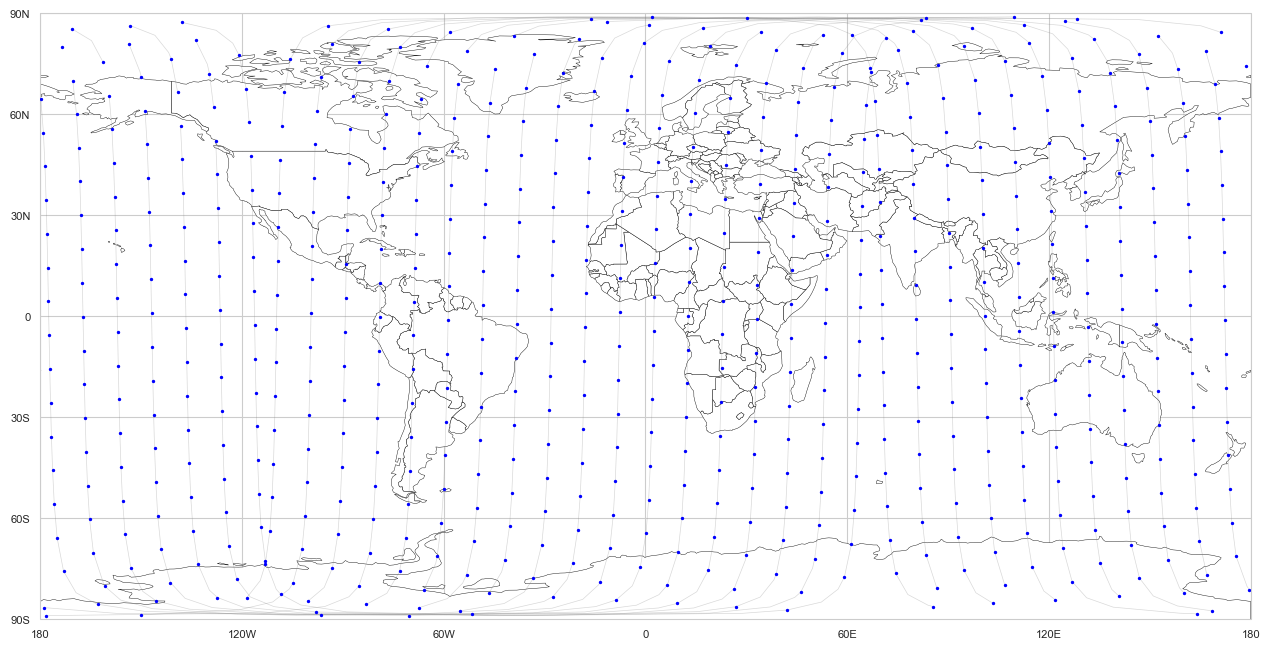

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas
import cartopy.crs as ccrs
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from cartopy.io import shapereader as shpreader
import json

# ================== 参数设置 ==================
P = 36  # 每个轨道的卫星数量 (根据您的提示: N=36)
# 如果您的 P 不是 36，请修改这个值。例如有些星座 P=22, P=66 等。

# 读取世界底图（用 cartopy 的 natural_earth）
shpfilename = shpreader.natural_earth(
    resolution="110m", category="cultural", name="admin_0_countries"
)
world = geopandas.read_file(shpfilename)

# 创建投影坐标轴
fig, ax = plt.subplots(
    figsize=(12.8, 7.2),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

# 画国家边界
world.plot(
    facecolor="white",
    edgecolor="black",
    linewidth=0.3,
    ax=ax,
)

# 从 snapshot100.json 读取所有卫星并绘制
with open("../paper_dataresult/snapshot_100.json", "r", encoding="utf-8") as f:
    snapshot = json.load(f)

sat_list = snapshot.get("satellites", [])

# ================== 修正后的分组逻辑 ==================
# 使用 id // P 作为 key 来分组卫星
satellites_by_orbit = {}

for s in sat_list:
    lat = s.get("lat")
    lon = s.get("lng", s.get("lon"))
    if lat is None or lon is None:
        continue

    sat_id = int(s.get("id"))  # 确保 ID 是整数

    # 核心修正：根据 ID // P 计算轨道编号
    orbit_id = sat_id // P

    if orbit_id not in satellites_by_orbit:
        satellites_by_orbit[orbit_id] = []

    satellites_by_orbit[orbit_id].append((sat_id, lat, lon))

# ================== 绘图逻辑 ==================

# 1. 绘制卫星点
for orbit_id, group in satellites_by_orbit.items():
    lats = [s[1] for s in group]
    lons = [s[2] for s in group]
    ax.scatter(
        lons, lats, transform=ccrs.PlateCarree(),
        s=2, color="blue", marker="o", zorder=5
    )

# 2. 绘制同轨链路
for orbit_id, group in satellites_by_orbit.items():

    # 核心修正：按 ID 排序而不是按经度排序
    # 同轨卫星的 ID 通常是连续的，按 ID 排序能保证它们在轨道圆环上的正确顺序
    group.sort(key=lambda x: x[0])

    # 提取经纬度
    lats = [s[1] for s in group]
    lons = [s[2] for s in group]

    if not lons:
        continue

    # 逐段绘制
    num_sats = len(group)

    # 遍历这个轨道内的每颗卫星，连接到下一颗
    # 如果是完整的环形轨道，最后一颗应该连回第一颗吗？
    # 如果您的 ID 是严格 0~35, 36~71... 那么 i 和 i+1 确实是相邻的。
    # 最后一颗 (ID 35) 和第一颗 (ID 0) 是否物理相邻取决于星座设计。
    # 为了保险，我们先只连 i -> i+1。

    for i in range(num_sats - 1):
        lon1, lat1 = lons[i], lats[i]
        lon2, lat2 = lons[i+1], lats[i+1]

        # 检查经度跳变 (跨越日界线)
        if abs(lon2 - lon1) > 180:
            continue

        # 使用 Geodetic 变换绘制两点间的曲线
        ax.plot(
            [lon1, lon2], [lat1, lat2],
            transform=ccrs.Geodetic(),
            color="gray",
            linestyle='-',
            linewidth=0.5,
            zorder=3,
            alpha=0.3
        )

    # 如果需要闭合轨道（连接最后一颗和第一颗），可以取消下面注释
    # 且需要判断 ID 是否真的是首尾衔接
    # last_sat = group[-1]
    # first_sat = group[0]
    # if abs(last_sat[2] - first_sat[2]) <= 180: # 简单防跨日界线检查
    #    ax.plot([last_sat[2], first_sat[2]], [last_sat[1], first_sat[1]],
    #            transform=ccrs.Geodetic(), color="gray", linestyle='-', linewidth=0.5, zorder=3, alpha=0.3)


# 设置显示范围
ax.set_extent([-180, 180, -90, 90], crs=ccrs.PlateCarree())

# 经纬度刻度
xticks = np.arange(-180, 181, 60)
yticks = np.arange(-90, 91, 30)
ax.set_xticks(xticks, crs=ccrs.PlateCarree())
ax.set_yticks(yticks, crs=ccrs.PlateCarree())
lon_formatter = LongitudeFormatter(number_format='.0f', degree_symbol='')
lat_formatter = LatitudeFormatter(number_format='.0f', degree_symbol='')
ax.xaxis.set_major_formatter(lon_formatter)
ax.yaxis.set_major_formatter(lat_formatter)

ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig("world_map_fixed_orbit_linking.pdf", dpi=300, bbox_inches="tight", pad_inches=0)
plt.show()